# Vergleich: Standard DQN vs. Deep Lattice (SB03, T_d = 50)

Beide Agenten werden mit identischen Hyperparametern auf derselben Instanz trainiert. Anschließend werden die Reward-Kurven in einem gemeinsamen Plot dargestellt, um das Konvergenzverhalten zu vergleichen.

In [15]:
import sys
import random
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))  # "Programming Part" auf sys.path

from env import gymnasium_env as drausp_env
import numpy as np
import torch

from env.instance_reader import get_instance_data
import matplotlib.pyplot as plt

from training.dqn_agent import DQNAgent
from models.standard_dqn import DQNNetwork
from models.deep_lattice import DeepLatticeNetwork

data_path = Path("../../instances/lion18s/SB03.txt")

In [16]:
DRAUSP_data = get_instance_data(data_path)

K = DRAUSP_data.num_slots
T_d = 10  # Anzahl Anfragen pro Episode
C_k = DRAUSP_data.capacity_vector
instance = DRAUSP_data.instance
request_lengths = DRAUSP_data.request_length
pool_size = DRAUSP_data.pool_size

print(f"Number of slots (K): {K}")
print(f"Number of requests per episode (T_d): {T_d}")
print(f"Pool size (|N|): {pool_size}")
print(f"Capacity vector (C_k): {C_k}")

NUM_EPISODES = 10000
SEED = 42

def make_env():
    return drausp_env.DrauspEnv(K=K, T_d=T_d, C_k=C_k, instance=instance, render_mode="human", fixed_request_length=request_lengths)

def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

Number of slots (K): 8
Number of requests per episode (T_d): 10
Pool size (|N|): 50
Capacity vector (C_k): [10, 10, 10, 10, 10, 10, 10, 10]


## Training Standard DQN

In [18]:
set_seed(SEED)
env_dqn = make_env()

agent_dqn = DQNAgent(
    env_dqn,
    QnetworkClass=DQNNetwork,
    monotonicity_penalty=False,
    reject_bias=0.75,
    gamma=0.99,
    epsilon_decay_steps=10000,
)

reward_history_dqn, mono_dqn, depth_history_dqn = agent_dqn.train(num_episodes=NUM_EPISODES)

  Systematic monotonicity (Episode 1): C_k: 58.4%, t: 72.4%, r: 55.5%, q: 44.5%, mixed: 68.3%
Episode   50/10000  Reward:     2.86  Avg(50):     1.51  Tiefe:   10  Avg-Tiefe(50):   10.0  ε: 0.954
  Systematic monotonicity (Episode 51): C_k: 64.0%, t: 65.2%, r: 41.4%, q: 46.1%, mixed: 74.8%
Episode  100/10000  Reward:     1.26  Avg(50):     1.43  Tiefe:   10  Avg-Tiefe(50):   10.0  ε: 0.910
  Systematic monotonicity (Episode 101): C_k: 100.0%, t: 83.5%, r: 64.2%, q: 4.8%, mixed: 100.0%
Episode  150/10000  Reward:     0.26  Avg(50):     1.73  Tiefe:   10  Avg-Tiefe(50):   10.0  ε: 0.868
  Systematic monotonicity (Episode 151): C_k: 100.0%, t: 93.2%, r: 87.9%, q: 22.1%, mixed: 100.0%
Episode  200/10000  Reward:     1.13  Avg(50):     1.77  Tiefe:   10  Avg-Tiefe(50):   10.0  ε: 0.828
  Systematic monotonicity (Episode 201): C_k: 100.0%, t: 100.0%, r: 91.9%, q: 57.7%, mixed: 100.0%
Episode  250/10000  Reward:     1.87  Avg(50):     2.19  Tiefe:   10  Avg-Tiefe(50):   10.0  ε: 0.790
  Syste

## Training Deep Lattice

In [19]:
set_seed(SEED)
env_lattice = make_env()

agent_lattice = DQNAgent(
    env_lattice,
    QnetworkClass=lambda input_dim, output_dim: DeepLatticeNetwork(
        input_dim     = input_dim,
        output_dim    = output_dim,
        c_range       = (0.0, 10.0),
        t_range       = (1.0, float(T_d)),
        r_range       = (0.0, 1.0),
        q_range       = (0.0, 10.0)
    ),
    monotonicity_penalty=False,
    reject_bias=0.75,
    gamma=0.99,
    epsilon_decay_steps=10000,
)

reward_history_lattice, mono_lattice, depth_history_lattice = agent_lattice.train(num_episodes=NUM_EPISODES)

  Systematic monotonicity (Episode 1): C_k: 100.0%, t: 100.0%, r: 100.0%, q: 100.0%, mixed: 100.0%
Episode   50/10000  Reward:     1.89  Avg(50):     1.36  Tiefe:   10  Avg-Tiefe(50):   10.0  ε: 0.954
  Systematic monotonicity (Episode 51): C_k: 100.0%, t: 100.0%, r: 100.0%, q: 100.0%, mixed: 100.0%
Episode  100/10000  Reward:     1.62  Avg(50):     1.40  Tiefe:   10  Avg-Tiefe(50):   10.0  ε: 0.910
  Systematic monotonicity (Episode 101): C_k: 100.0%, t: 100.0%, r: 100.0%, q: 100.0%, mixed: 100.0%
Episode  150/10000  Reward:     0.41  Avg(50):     1.61  Tiefe:   10  Avg-Tiefe(50):   10.0  ε: 0.868
  Systematic monotonicity (Episode 151): C_k: 100.0%, t: 100.0%, r: 100.0%, q: 100.0%, mixed: 100.0%
Episode  200/10000  Reward:     2.19  Avg(50):     1.69  Tiefe:   10  Avg-Tiefe(50):   10.0  ε: 0.828
  Systematic monotonicity (Episode 201): C_k: 100.0%, t: 100.0%, r: 100.0%, q: 100.0%, mixed: 100.0%
Episode  250/10000  Reward:     1.56  Avg(50):     2.28  Tiefe:   10  Avg-Tiefe(50):    9.

## Vergleich der Reward-Kurven

Rohe Episoden-Rewards (transparent) und gleitender Mittelwert beider Agenten in einem Plot. Die gestrichelten Linien markieren die Episode, ab der der gleitende Mittelwert erstmals 95 % seines Endniveaus (Mittel der letzten 500 Episoden) erreicht.

Standard DQN   Endniveau (letzte 500): 4.683  95%-Konvergenz bei Episode: 2347
Deep Lattice   Endniveau (letzte 500): 4.616  95%-Konvergenz bei Episode: 1764


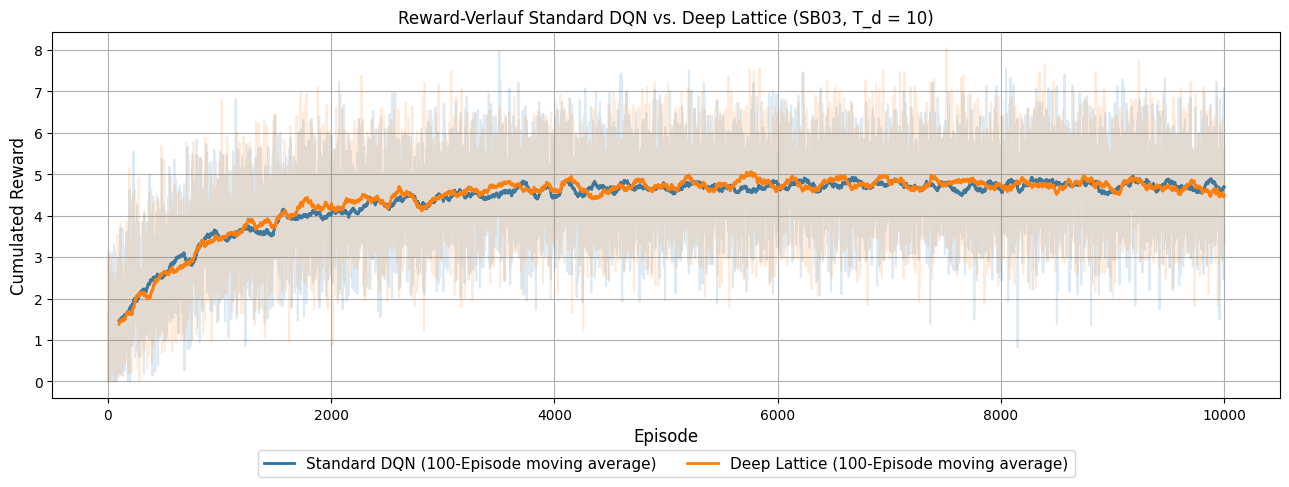

In [20]:
WINDOW = 100
FINAL_WINDOW = 500
THRESHOLD = 0.95

def moving_average(r, window):
    r = np.asarray(r)
    return np.convolve(r, np.ones(window) / window, mode="valid")

def convergence_episode(r, window=WINDOW, final_window=FINAL_WINDOW, threshold=THRESHOLD):
    """Erste Episode, in der der gleitende Mittelwert threshold * Endniveau erreicht."""
    r = np.asarray(r)
    final_level = r[-final_window:].mean()
    mov = moving_average(r, window)
    idx = np.where(mov >= threshold * final_level)[0]
    return (int(idx[0] + window - 1) if len(idx) > 0 else None), final_level

runs = {
    "Standard DQN": (reward_history_dqn, "tab:blue"),
    "Deep Lattice": (reward_history_lattice, "tab:orange"),
}

fig, ax = plt.subplots(figsize=(13, 5))
for name, (r, color) in runs.items():
    r = np.asarray(r)
    ax.plot(r, color=color, alpha=0.15)
    mov = moving_average(r, WINDOW)
    ax.plot(np.arange(WINDOW - 1, len(r)), mov, color=color, linewidth=2, label=f"{name} ({WINDOW}-Episode moving average)")

    conv_ep, final_level = convergence_episode(r)
    #if conv_ep is not None:
        #ax.axvline(conv_ep, color=color, linestyle="--", linewidth=1.2,
         #          label=f"{name}: {int(THRESHOLD*100)} % des Endniveaus bei Episode {conv_ep}")
    print(f"{name:13s}  Endniveau (letzte {FINAL_WINDOW}): {final_level:.3f}  "
          f"{int(THRESHOLD*100)}%-Konvergenz bei Episode: {conv_ep}")

ax.set_xlabel("Episode", fontsize=12)
ax.set_ylabel("Cumulated Reward", fontsize=12)
ax.set_title(f"Reward-Verlauf Standard DQN vs. Deep Lattice (SB03, T_d = {T_d})")
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.12), ncol=2, fontsize=11)
ax.grid(True)
fig.tight_layout()
plt.show()

## Episodentiefe und Epsilon (optional)

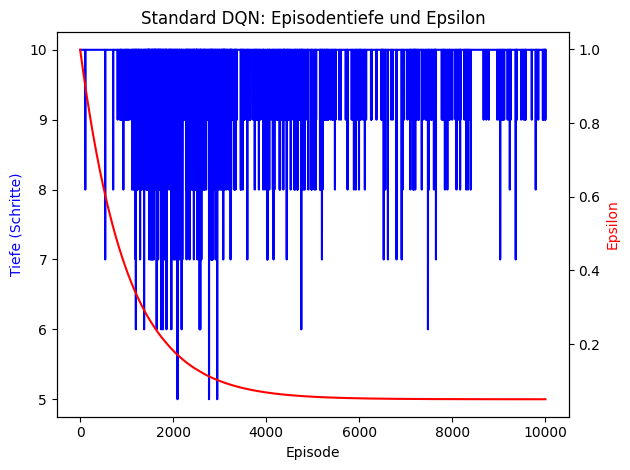

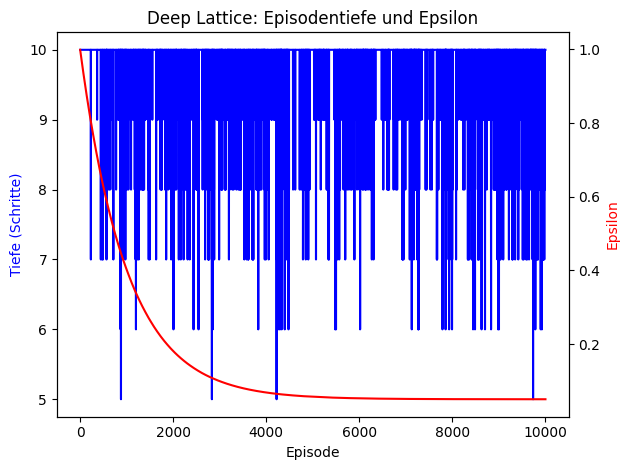

In [21]:
from training.plotting import plot_depth_epsilon

plot_depth_epsilon(depth_history_dqn, title="Standard DQN: Episodentiefe und Epsilon")
plot_depth_epsilon(depth_history_lattice, title="Deep Lattice: Episodentiefe und Epsilon")